# MCF7 - Drop-seq - Unsupervised Analysis

## Introduction
This notebook performs unsupervised analysis on the MCF7 Drop-seq filtered and normalised gene expression dataset. We follow the same pipeline as the MCF7 SMART-seq analysis.

In [ ]:
!pip install pandas numpy matplotlib scikit-learn seaborn scipy umap-learn


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## 1. Libraries and Imports

In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, confusion_matrix, silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import mean_squared_error
import plotly.express as px
from umap import UMAP
import os

print("All libraries loaded successfully")

All libraries loaded successfully


## 2. Loading and Preparing the Data

We load the filtered and normalised gene expression matrix for MCF7 Drop-seq. Drop-seq is a higher throughput but lower resolution technology compared to SMART-seq, measuring many more cells but with less detail per cell. The dataset contains 3000 genes as rows and 21,626 cells as columns. We transpose it so that rows represent cells and columns represent genes, and extract the true biological labels from the cell names.

In [ ]:
os.chdir('/Users/laviniaskandalis/Documents/Hypoxia_Project')

df = pd.read_csv('MCF7_Filtered_Normalised_3000_Data_train.txt', sep=' ', index_col=0)
print(f"Shape (genes x cells): {df.shape}")
df.head()

Shape (genes x cells): (3000, 21626)


,AAAAACCTATCG_Normoxia,AAAACAACCCTA_Normoxia,AAAACACTCTCA_Normoxia,AAAACCAGGCAC_Normoxia,AAAACCTAGCTC_Normoxia,AAAACCTCCGGG_Normoxia,AAAACTCGTTGC_Normoxia,AAAAGAGCTCTC_Normoxia,AAAAGCTAGGCG_Normoxia,AAAATCGCATTT_Normoxia,...,TTTTACAGGATC_Hypoxia,TTTTACCACGTA_Hypoxia,TTTTATGCTACG_Hypoxia,TTTTCCAGACGC_Hypoxia,TTTTCGCGCTCG_Hypoxia,TTTTCGCGTAGA_Hypoxia,TTTTCGTCCGCT_Hypoxia,TTTTCTCCGGCT_Hypoxia,TTTTGTTCAAAG_Hypoxia,TTTTTTGTATGT_Hypoxia
MALAT1,1,3,3,6,4,5,1,13,3,3,...,0,2,1,0,1,0,1,0,0,4
MT-RNR2,0,0,0,2,0,0,2,1,7,0,...,0,0,0,0,0,0,0,0,0,0
NEAT1,0,0,0,0,0,2,0,1,2,0,...,0,0,0,0,0,0,0,0,0,0
H1-5,0,0,0,0,0,2,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
TFF1,4,1,1,1,0,0,0,2,0,1,...,2,3,8,0,0,3,4,2,6,0


In [ ]:
df_T = df.T
print(f"Shape after transpose (cells x genes): {df_T.shape}")
df_T.head()

Shape after transpose (cells x genes): (21626, 3000)


,MALAT1,MT-RNR2,NEAT1,H1-5,TFF1,MT-RNR1,H4C3,GDF15,KRT81,MT-CO3,...,MROH1,SKIDA1,MICALL1,RARG,MYO1F,BRWD1-AS2,RPS19BP1,AUNIP,TNK2,SUDS3
AAAAACCTATCG_Normoxia,1,0,0,0,4,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAACAACCCTA_Normoxia,3,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAACACTCTCA_Normoxia,3,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAACCAGGCAC_Normoxia,6,2,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAACCTAGCTC_Normoxia,4,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
true_labels = pd.Series(df_T.index.map(lambda x: 'Hypo' if 'Hypoxia' in x else 'Norm'), index=df_T.index)

print(f"Hypo cells: {sum(true_labels=='Hypo')}")
print(f"Norm cells: {sum(true_labels=='Norm')}")

Hypo cells: 8921
Norm cells: 12705


## 3. Unsupervised Analysis

### 3.1 PCA

Before running PCA we scale the data using StandardScaler to ensure every gene contributes equally regardless of its expression magnitude.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_T)
print(f"Scaled data shape: {X_scaled.shape}")

Scaled data shape: (21626, 3000)


#### Finding the right number of components

We run PCA with n_components=0.95 to automatically find however many components are needed to explain 95% of the variance.

In [ ]:
pca = PCA(n_components=0.95)
X_pca_95 = pca.fit_transform(X_scaled)

print("Number of components:", pca.n_components_)
print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
print("Reconstruction error:", mean_squared_error(pca.inverse_transform(X_pca_95), X_scaled))

Number of components: 2654
Explained variation per principal component: [0.00674412 0.00249983 0.00156054 ... 0.00016683 0.00016669 0.0001666 ]
Reconstruction error: 0.04996190395460413


2654 principal components are needed to explain 95% of the variance in the Drop-seq dataset. This is significantly more than the 205 components required for SMART-seq, reflecting the much larger number of cells (21,626 vs 250) and the lower sequencing depth per cell characteristic of Drop-seq technology. PC1 explains only 0.67% of variance compared to 7.8% in SMART-seq, indicating the variance is more evenly distributed across dimensions.

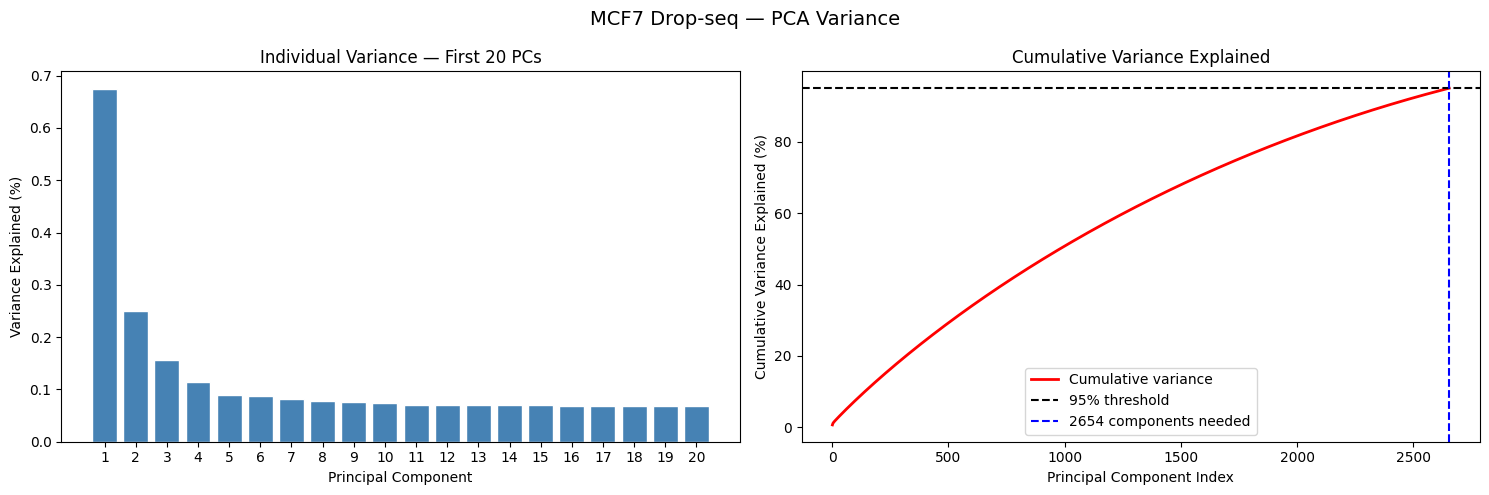

In [ ]:
exp_var = pca.explained_variance_ratio_ * 100
cum_sum = np.cumsum(exp_var)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(range(1, 21), exp_var[:20], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Individual Variance — First 20 PCs')
axes[0].set_xticks(range(1, 21))

axes[1].plot(range(1, len(cum_sum)+1), cum_sum, color='red', linewidth=2, label='Cumulative variance')
axes[1].axhline(y=95, color='black', linestyle='--', label='95% threshold')
axes[1].axvline(x=pca.n_components_, color='blue', linestyle='--', label=f'{pca.n_components_} components needed')
axes[1].set_xlabel('Principal Component Index')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()

plt.suptitle('MCF7 Drop-seq — PCA Variance', fontsize=14)
plt.tight_layout()
plt.savefig('PCA_variance_MCF7_dropseq.png', dpi=150)
plt.show()

Shows how much of the total variation in the data each principal component captures individually as bars, and cumulatively as a step line, so we can see how dominant PC1 is and how many components are needed to explain 95% of the variance.

#### Visualising the first 5 principal components

Plotting the first 5 components against each other reveals how cells are distributed across multiple dimensions.

In [ ]:
import plotly.io as pio
pio.renderers.default = 'notebook'

n_components = 5
pca_5 = PCA(n_components=n_components)
components = pca_5.fit_transform(X_scaled)

total_var = pca_5.explained_variance_ratio_.sum() * 100

components_df = pd.DataFrame(components, columns=[f'PC{i+1}' for i in range(n_components)])
components_df['Condition'] = true_labels.values

fig = px.scatter_matrix(
    components_df,
    color='Condition',
    dimensions=[f'PC{i+1}' for i in range(n_components)],
    title=f'MCF7 Drop-seq — Total Explained Variance: {total_var:.2f}%',
    color_discrete_map={'Hypo': '#e74c3c', 'Norm': '#3498db'}
)
fig.update_traces(diagonal_visible=False, marker=dict(size=3, opacity=0.5))
fig.show()

The scatter matrix confirms that separation between hypoxic and normoxic cells is primarily driven by PC1, with progressively less separation in higher components. This is consistent with the variance plot showing PC1 as the dominant component.

#### Visualisation in 2D

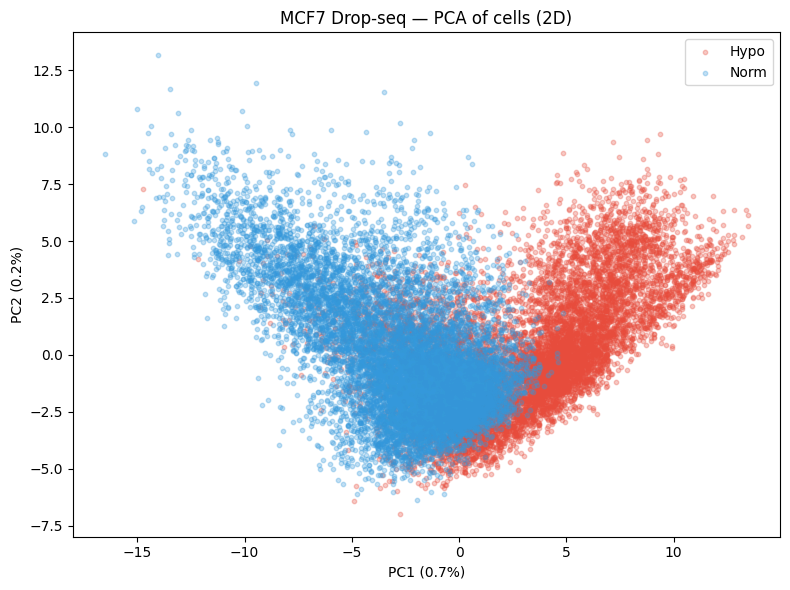

In [ ]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
explained_2d = pca_2d.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 6))
for condition, color in [('Hypo', '#e74c3c'), ('Norm', '#3498db')]:
    mask = true_labels == condition
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                label=condition, color=color, alpha=0.3, s=10)

plt.xlabel(f'PC1 ({explained_2d[0]:.1f}%)')
plt.ylabel(f'PC2 ({explained_2d[1]:.1f}%)')
plt.title('MCF7 Drop-seq — PCA of cells (2D)')
plt.legend()
plt.tight_layout()
plt.savefig('PCA_2D_MCF7_dropseq.png', dpi=150)
plt.show()

The 2D PCA plot shows separation between hypoxic and normoxic cells along PC1, however with considerably more overlap than observed in the SMART-seq dataset. This is consistent with Drop-seq's lower sequencing depth per cell, which introduces more noise and reduces the clarity of the biological signal.

#### Visualisation in 3D

Elevation: 20  Azimuth: 120


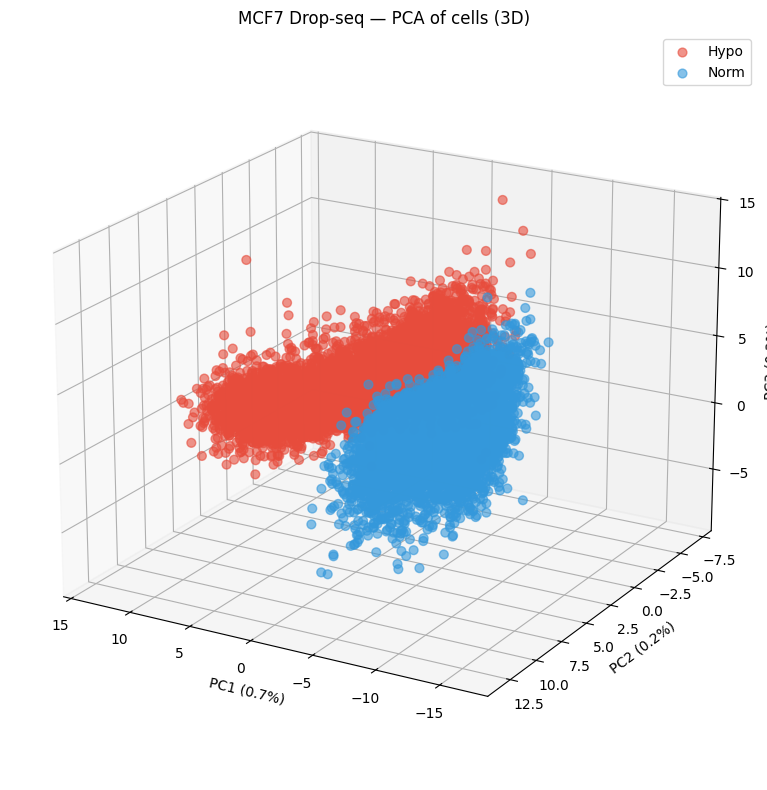

In [ ]:
def PCA_3(EL, AZ):
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_scaled)
    explained_3d = pca_3d.explained_variance_ratio_ * 100

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for condition, color in [('Hypo', '#e74c3c'), ('Norm', '#3498db')]:
        mask = true_labels == condition
        ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
                   label=condition, color=color, alpha=0.6, s=40)

    ax.set_xlabel(f'PC1 ({explained_3d[0]:.1f}%)')
    ax.set_ylabel(f'PC2 ({explained_3d[1]:.1f}%)')
    ax.set_zlabel(f'PC3 ({explained_3d[2]:.1f}%)')
    ax.set_title('MCF7 Drop-seq — PCA of cells (3D)')
    ax.legend()
    ax.view_init(elev=EL, azim=AZ)
    print(f"Elevation: {EL}  Azimuth: {AZ}")
    plt.tight_layout()
    plt.savefig(f'PCA_3D_dropseq_el{EL}_az{AZ}.png', dpi=150)
    plt.show()

PCA_3(20, 120)

Elevation: 45  Azimuth: 200


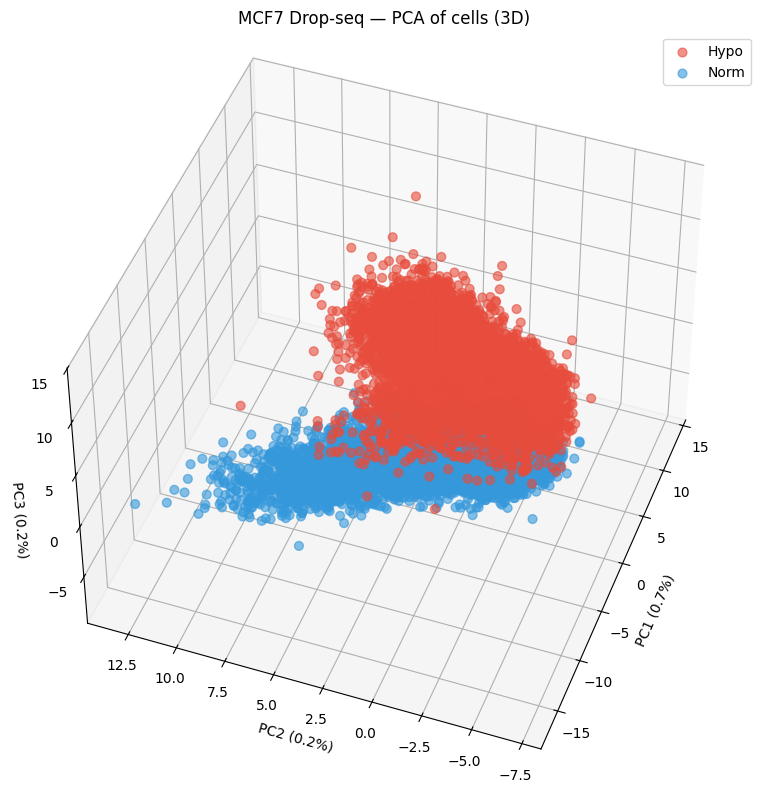

In [ ]:
PCA_3(45, 200)

The variance explained by PC3 (0.2%) is comparable to PC2 (0.2%), indicating that the third component is also relevant and that the 3D visualisation reveals additional structure in the separation between hypoxic and normoxic cells.

### 3.2 Clustering

#### 3.2.1 K-Means

##### Elbow Method

Note: Due to the large size of the Drop-seq dataset (21,626 cells), we run all clustering on the PCA-reduced data (X_pca_95) rather than the full scaled data. This improves convergence and stability of the clustering algorithms, which struggle with the high dimensionality and noise of the raw Drop-seq data.

In [ ]:
X_cluster = X_pca_95[:, :50]
print(f"Shape for clustering: {X_cluster.shape}")

Shape for clustering: (21626, 50)


In [1]:
def clustering_accuracy(clust_labels, og_labels):
    print("Clustering accuracy:",
          max(np.count_nonzero(clust_labels == og_labels) * 100 / len(og_labels),
              100 - np.count_nonzero(clust_labels == og_labels) * 100 / len(og_labels)),
          "%")

def diagnoses(kmeans_model, data):
    n_clusters = kmeans_model.n_clusters
    labels = kmeans_model.labels_
    centers = kmeans_model.cluster_centers_

    cardinality = [np.sum(labels == i) for i in range(n_clusters)]

    magnitude = []
    for i in range(n_clusters):
        cluster_points = data[labels == i]
        distances = np.linalg.norm(cluster_points - centers[i], axis=1)
        magnitude.append(np.sum(distances))

    bar_colors = ['#e74c3c', '#3498db', '#2ecc71'][:n_clusters]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].bar(range(n_clusters), cardinality, color=bar_colors)
    axes[0].set_xlabel('Cluster Label')
    axes[0].set_ylabel('Points in Cluster')
    axes[0].set_title('Cardinality')
    axes[0].set_xticks(range(n_clusters))

    axes[1].bar(range(n_clusters), magnitude, color=bar_colors)
    axes[1].set_xlabel('Cluster Label')
    axes[1].set_ylabel('Total Point-to-Centroid Distance')
    axes[1].set_title('Magnitude')
    axes[1].set_xticks(range(n_clusters))

    plt.tight_layout()
    plt.show()

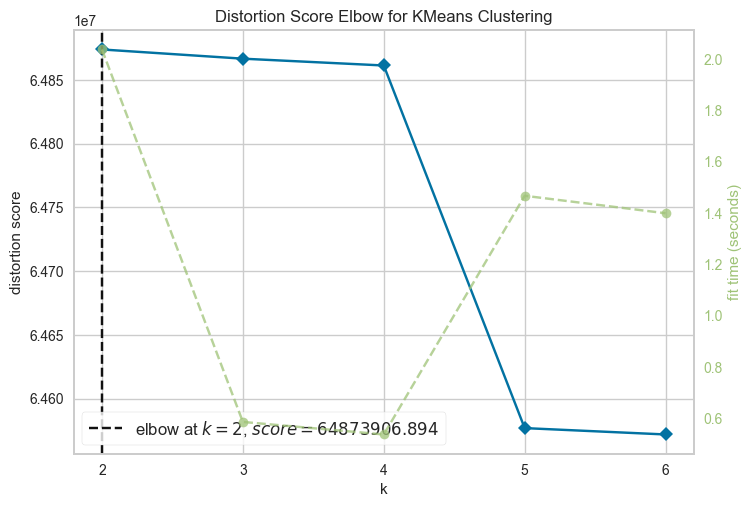

<Figure size 800x550 with 0 Axes>

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

fig, ax = plt.subplots()
visualizer = KElbowVisualizer(KMeans(random_state=42), k=(2,7), ax=ax, force_model=True)
visualizer.fit(X_scaled)
ax.set_xticks(range(2,7))
visualizer.show()
plt.savefig('elbow_MCF7_dropseq.png', dpi=150)
plt.show()

The elbow method detects the elbow at K=2, consistent with our two known biological conditions of hypoxia and normoxia. We proceed with both K=2 and K=3 to explore whether additional structure exists within the data.

##### Silhouette Score

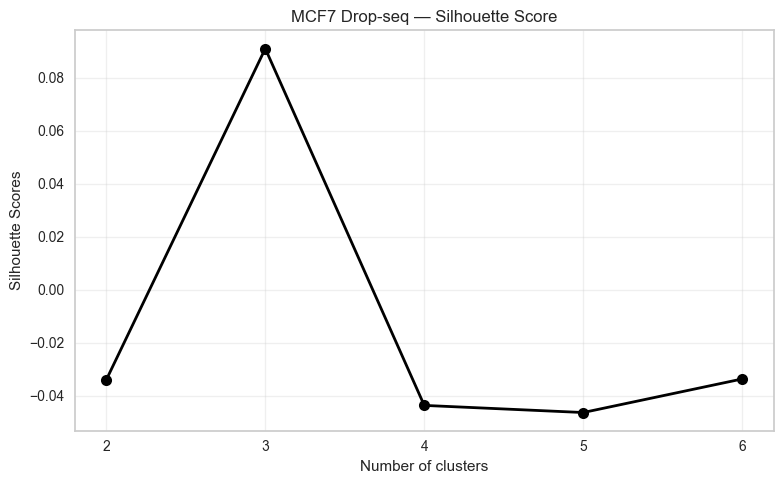

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k,
                max_iter=300,
                tol=1e-04,
                init='k-means++',
                n_init=10,
                random_state=42)
    km.fit(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 7), silhouette_scores, 'o-', color='black', linewidth=2, markersize=8)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Scores')
plt.title('MCF7 Drop-seq — Silhouette Score')
plt.xticks(range(2, 7))
plt.grid(visible=True, alpha=0.3)
plt.tight_layout()
plt.savefig('silhouette_score_MCF7_dropseq.png', dpi=150)
plt.show()

The silhouette score peaks at K=3, while the elbow method detected K=2. Given the conflicting signals from the two methods and our two known biological conditions, we proceed with both K=2 and K=3.

##### Silhouette Analysis

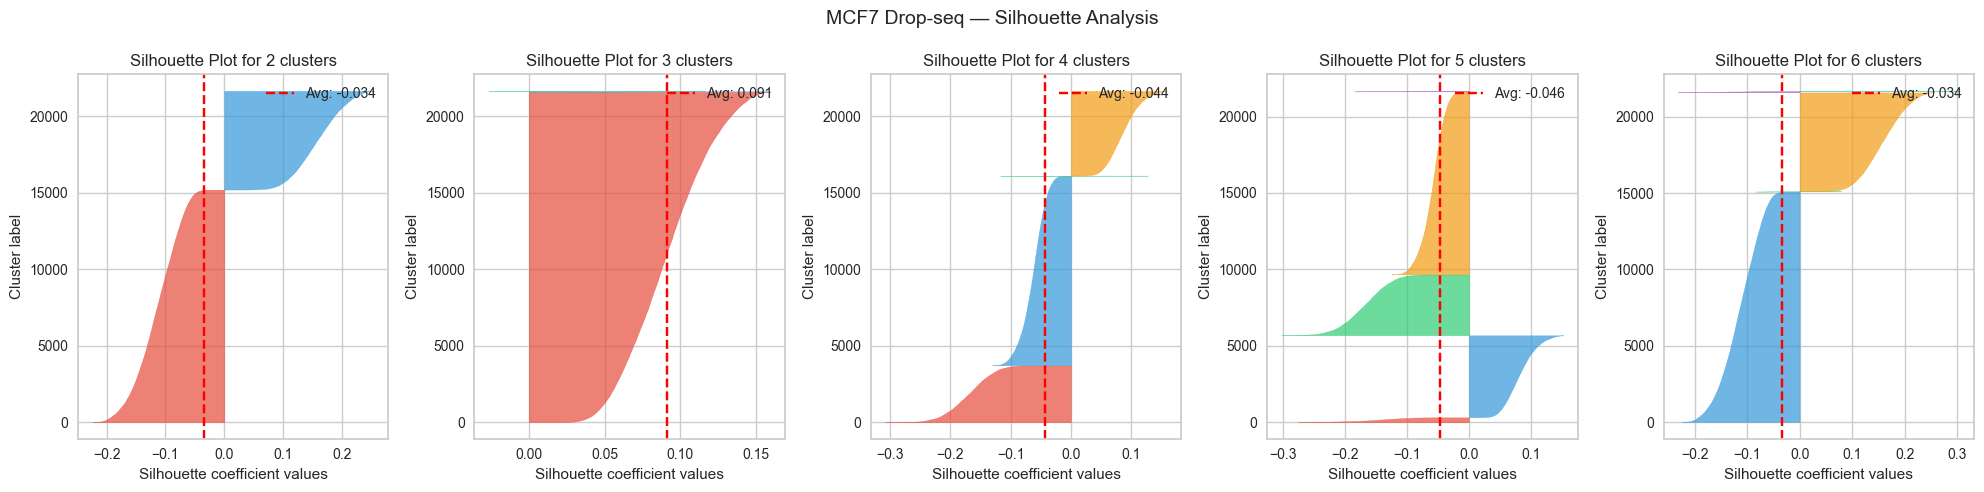

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes = axes.flatten()

cluster_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for idx, k in enumerate(range(2, 7)):
    km = KMeans(n_clusters=k,
                max_iter=300,
                tol=1e-04,
                init='k-means++',
                n_init=10,
                random_state=42)
    km.fit(X_scaled)

    sh_samples = silhouette_samples(X_scaled, km.labels_)
    sh_score = silhouette_score(X_scaled, km.labels_)

    y_lower = 10
    for i in range(k):
        values = sh_samples[km.labels_ == i]
        values.sort()
        size = values.shape[0]
        y_upper = y_lower + size
        axes[idx].fill_betweenx(np.arange(y_lower, y_upper), 0, values,
                                facecolor=cluster_colors[i], edgecolor=cluster_colors[i], alpha=0.7)
        y_lower = y_upper + 10

    axes[idx].axvline(x=sh_score, color='red', linestyle='--', label=f'Avg: {sh_score:.3f}')
    axes[idx].set_title(f'Silhouette Plot for {k} clusters')
    axes[idx].set_xlabel('Silhouette coefficient values')
    axes[idx].set_ylabel('Cluster label')
    axes[idx].legend(loc='upper right')

plt.suptitle('MCF7 Drop-seq — Silhouette Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('silhouette_analysis_MCF7_dropseq.png', dpi=150)
plt.show()

Analyzing these plots, K=3 shows the highest average silhouette score. However given that we have two known biological conditions, we proceed with both K=2 and K=3.

##### K-Means with K=2

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_scaled)
kmeans.labels_
print(f"Cluster 0: {sum(kmeans.labels_==0)} cells")
print(f"Cluster 1: {sum(kmeans.labels_==1)} cells")

Cluster 0: 15183 cells
Cluster 1: 6443 cells


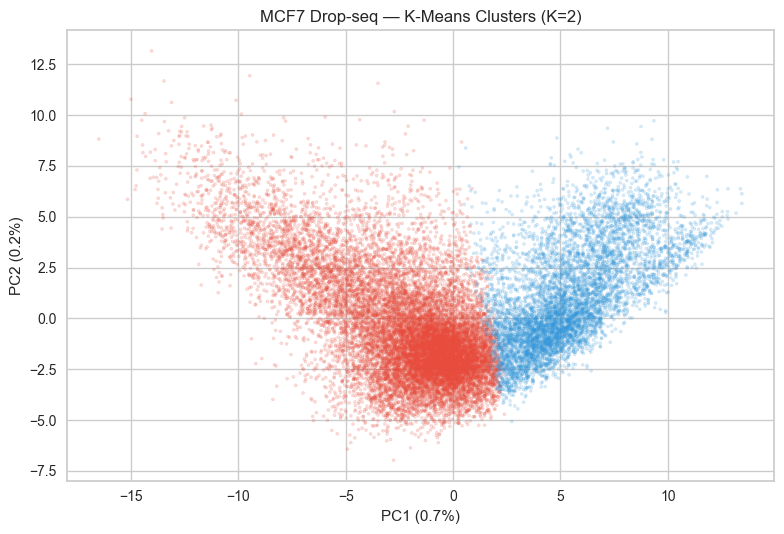

In [ ]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
explained_2d = pca_2d.explained_variance_ratio_ * 100

x = X_pca_2d[:, 0]
y = X_pca_2d[:, 1]
cluster_colors_plot = ['#e74c3c' if l==0 else '#3498db' for l in kmeans.labels_]
plt.scatter(x, y, c=cluster_colors_plot, alpha=0.2, s=5)
plt.xlabel(f'PC1 ({explained_2d[0]:.1f}%)')
plt.ylabel(f'PC2 ({explained_2d[1]:.1f}%)')
plt.title('MCF7 Drop-seq — K-Means Clusters (K=2)')
plt.tight_layout()
plt.savefig('kmeans_k2_dropseq.png', dpi=150)
plt.show()

The 2D PCA projection shows partial separation between the two clusters along PC1, consistent with the lower sequencing depth per cell characteristic of Drop-seq technology, which results in higher noise levels compared to SMART-seq.

Elevation: 20  Azimuth: 120


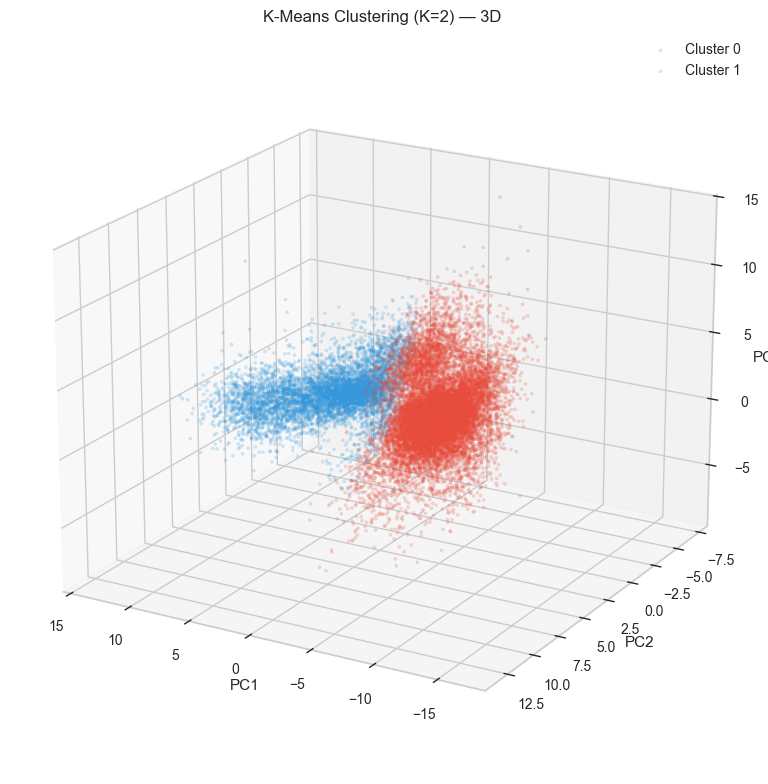

In [ ]:
def KM_plot(EL, AZ, kmeans_model):
    pca_3d = PCA(n_components=3)
    coords = pca_3d.fit_transform(X_scaled)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    colors = ['#e74c3c', '#3498db', '#2ecc71']
    for i in range(kmeans_model.n_clusters):
        mask = kmeans_model.labels_ == i
        ax.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2],
                   color=colors[i], alpha=0.2, s=5, label=f'Cluster {i}')

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title(f'K-Means Clustering (K={kmeans_model.n_clusters}) — 3D')
    ax.legend()
    ax.view_init(elev=EL, azim=AZ)
    print(f"Elevation: {EL}  Azimuth: {AZ}")
    plt.tight_layout()
    plt.show()

KM_plot(20, 120, kmeans)

Adjusted Rand Index: 0.503


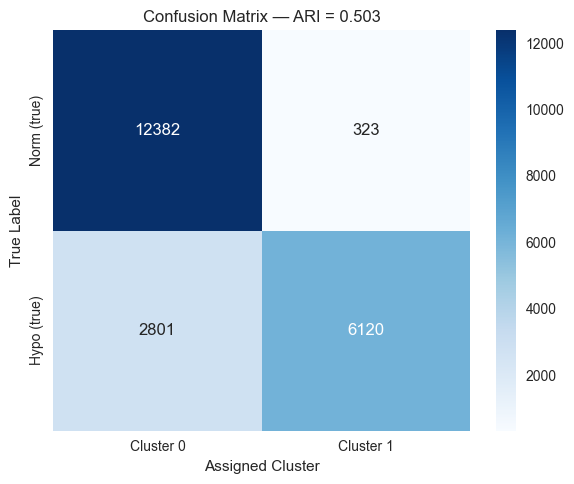

In [ ]:
true_numeric = (true_labels == 'Hypo').astype(int)
og_labels = true_numeric.values
ari = adjusted_rand_score(true_numeric, kmeans.labels_)
cm = confusion_matrix(true_numeric, kmeans.labels_)

print(f"Adjusted Rand Index: {ari:.3f}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=['Norm (true)', 'Hypo (true)'])
plt.title(f'Confusion Matrix — ARI = {ari:.3f}')
plt.ylabel('True Label')
plt.xlabel('Assigned Cluster')
plt.tight_layout()
plt.savefig('confusion_matrix_dropseq_k2.png', dpi=150)
plt.show()

In [ ]:
clustering_accuracy(og_labels, kmeans.labels_)

Clustering accuracy: 85.55442522889115 %


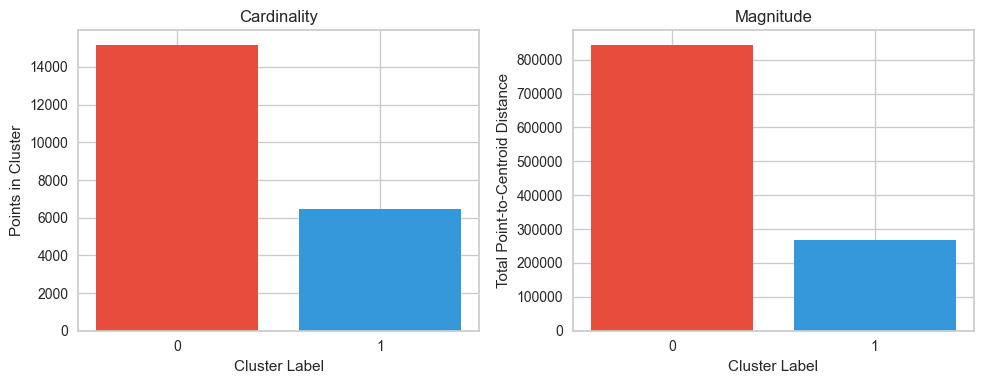

In [ ]:
diagnoses(kmeans, X_scaled)

K-Means with K=2 achieves an ARI of 0.503 and a clustering accuracy of 85.5%, considerably lower than the 98.8% achieved on SMART-seq. This reflects the higher noise levels in Drop-seq data. The cardinality plot shows an imbalanced split — 15,183 cells in cluster 0 and 6,443 in cluster 1 — compared to our known class balance of 12,705 normoxic and 8,921 hypoxic cells.

##### K-Means with K=3

In [ ]:
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_scaled)
kmeans3.labels_
print(f"Cluster 0: {sum(kmeans3.labels_==0)} cells")
print(f"Cluster 1: {sum(kmeans3.labels_==1)} cells")
print(f"Cluster 2: {sum(kmeans3.labels_==2)} cells")

Cluster 0: 21583 cells
Cluster 1: 20 cells
Cluster 2: 23 cells


K-Means with K=3 on the full scaled data produces a much worse solution, assigning 21,583 cells to a single cluster and only 20 and 23 cells to the other two. Despite this, we show the plots for completeness and to illustrate how K=3 fails to find meaningful structure in this dataset.

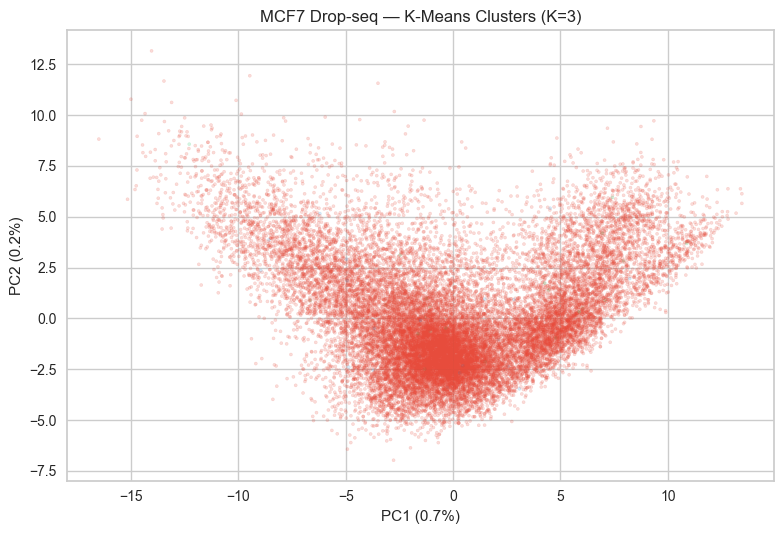

In [ ]:
x = X_pca_2d[:, 0]
y = X_pca_2d[:, 1]
colors_3 = ['#e74c3c', '#3498db', '#2ecc71']
cluster_colors_k3 = [colors_3[l] for l in kmeans3.labels_]
plt.scatter(x, y, c=cluster_colors_k3, alpha=0.2, s=5)
plt.xlabel(f'PC1 ({explained_2d[0]:.1f}%)')
plt.ylabel(f'PC2 ({explained_2d[1]:.1f}%)')
plt.title('MCF7 Drop-seq — K-Means Clusters (K=3)')
plt.tight_layout()
plt.savefig('kmeans_k3_dropseq.png', dpi=150)
plt.show()

Elevation: 20  Azimuth: 120


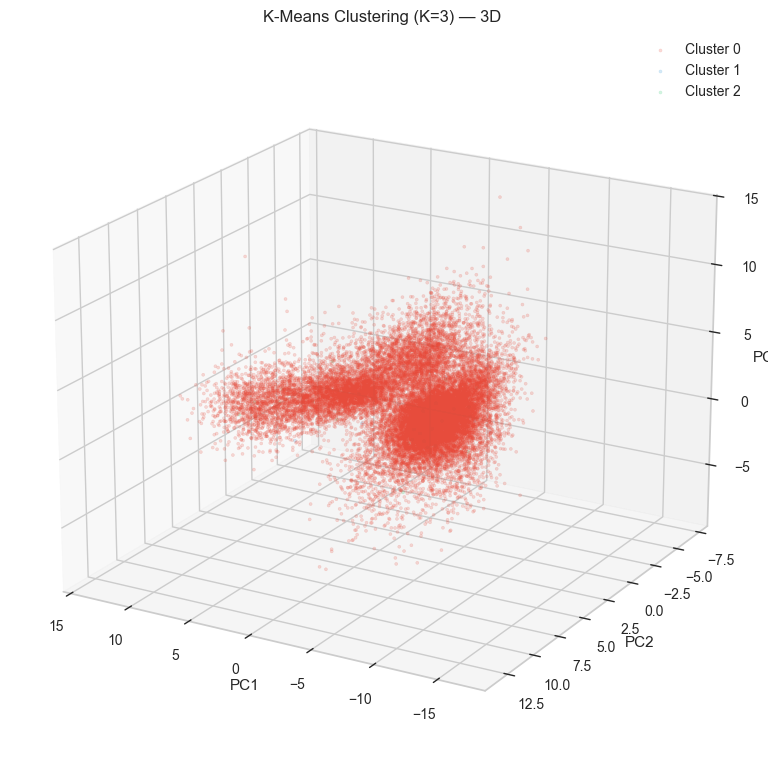

In [ ]:
KM_plot(20, 120, kmeans3)

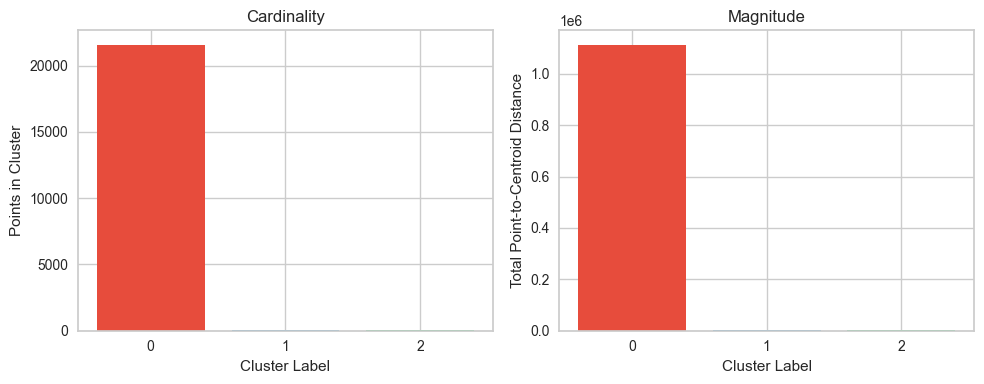

Clustering accuracy: 58.660871173587346 %


In [ ]:
diagnoses(kmeans3, X_scaled)
clustering_accuracy(og_labels, kmeans3.labels_)

#### 3.2.2 Agglomerative Clustering

Cluster 0: 16249 cells
Cluster 1: 5377 cells
ARI: 0.387


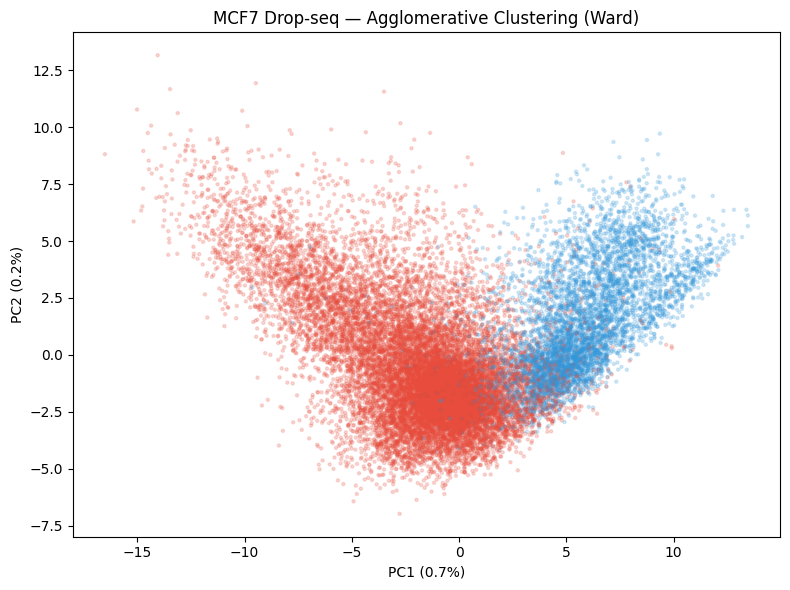

In [ ]:
agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
agglo_labels = agglo.fit_predict(X_cluster)

true_numeric = (true_labels == 'Hypo').astype(int)
ari_agglo = adjusted_rand_score(true_numeric, agglo_labels)

print(f"Cluster 0: {sum(agglo_labels==0)} cells")
print(f"Cluster 1: {sum(agglo_labels==1)} cells")
print(f"ARI: {ari_agglo:.3f}")

agglo_colors = ['#e74c3c' if l==0 else '#3498db' for l in agglo_labels]
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=agglo_colors, alpha=0.2, s=5)
plt.xlabel(f'PC1 ({explained_2d[0]:.1f}%)')
plt.ylabel(f'PC2 ({explained_2d[1]:.1f}%)')
plt.title('MCF7 Drop-seq — Agglomerative Clustering (Ward)')
plt.tight_layout()
plt.savefig('agglo_dropseq.png', dpi=150)
plt.show()

Agglomerative clustering with Ward linkage achieves an ARI of 0.387 on the Drop-seq dataset, lower than K-Means (0.505). Unlike SMART-seq where agglomerative clustering outperformed K-Means, the noisier Drop-seq data appears better suited to K-Means clustering.

##### Dendrogram

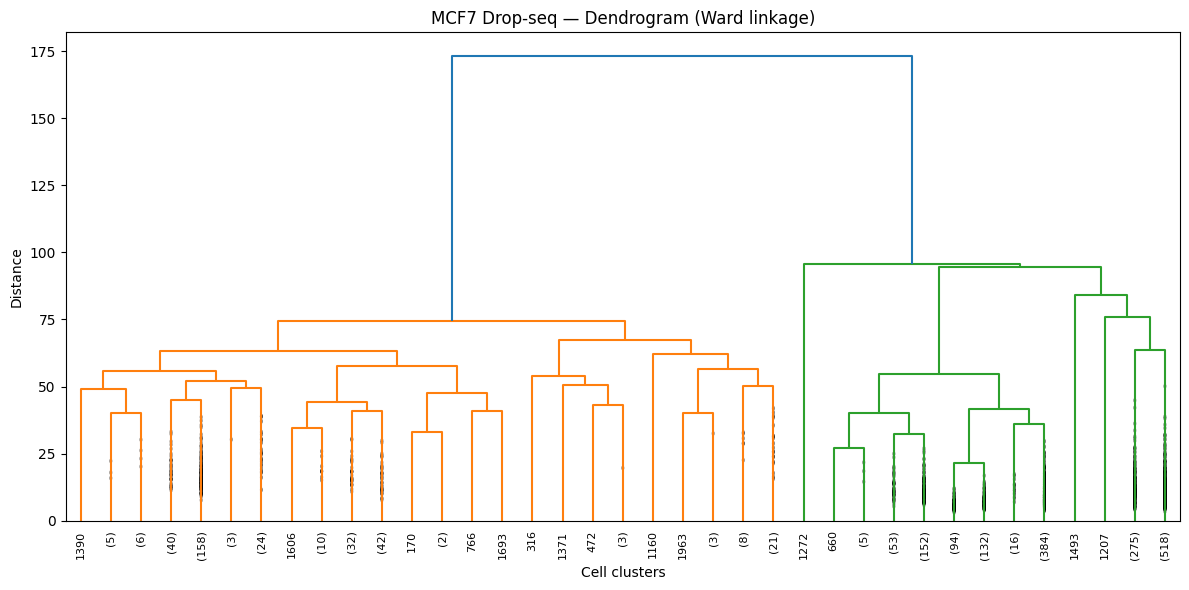

In [ ]:
linked = linkage(X_cluster[:2000], method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked,
           truncate_mode='level',
           p=5,
           leaf_rotation=90,
           leaf_font_size=8,
           show_contracted=True)
plt.title('MCF7 Drop-seq — Dendrogram (Ward linkage)')
plt.xlabel('Cell clusters')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogram_MCF7_dropseq.png', dpi=150)
plt.show()

#### 3.2.3 UMAP

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


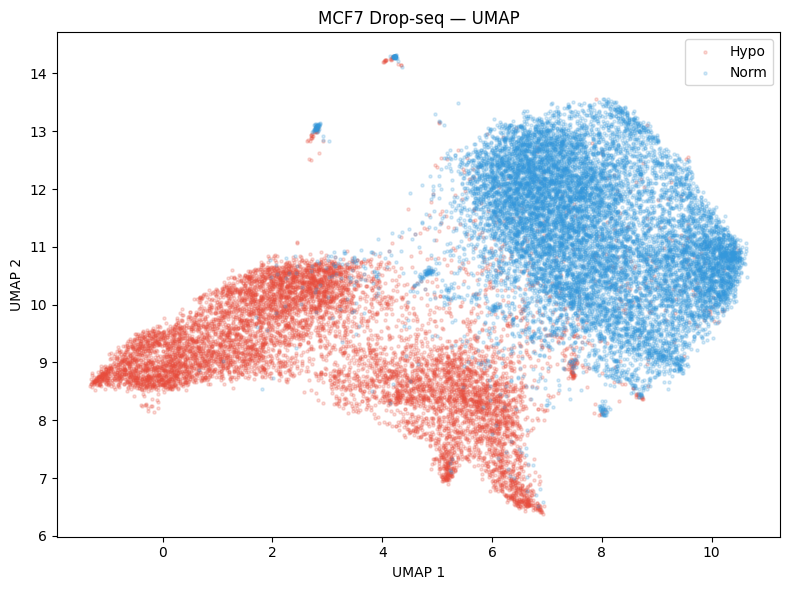

In [ ]:
from umap import UMAP

reducer = UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
for condition, color in [('Hypo', '#e74c3c'), ('Norm', '#3498db')]:
    mask = true_labels == condition
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1],
                label=condition, color=color, alpha=0.2, s=5)

plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('MCF7 Drop-seq — UMAP')
plt.legend()
plt.tight_layout()
plt.savefig('umap_MCF7_dropseq.png', dpi=150)
plt.show()

UMAP reveals considerably clearer separation between hypoxic and normoxic cells than PCA, with two distinct regions visible. This demonstrates that the hypoxia signal is present in the Drop-seq data but is non-linear — UMAP captures it better than PCA because it preserves local structure rather than just maximising variance. The small isolated clusters at the top likely represent outlier cells.

## 4. Conclusion

Unsupervised analysis of the MCF7 Drop-seq dataset reveals a weaker but still detectable separation between hypoxic and normoxic cells compared to SMART-seq.

PCA required 2654 components to explain 95% of variance, with PC1 capturing only 0.7% — significantly lower than SMART-seq's 7.8% — reflecting the higher noise and lower sequencing depth per cell of Drop-seq technology.

K-Means clustering with K=2 achieved an ARI of 0.505, and agglomerative clustering with Ward linkage achieved an ARI of 0.387 — both considerably lower than the corresponding SMART-seq results (0.952 and 0.984). UMAP revealed clearer separation than PCA, confirming that the hypoxia signal exists but is non-linear in the Drop-seq data.

Overall, these results demonstrate that while the hypoxia signal is detectable in Drop-seq data, SMART-seq provides significantly cleaner and more reliable separation between conditions, highlighting the importance of sequencing technology choice for downstream classification tasks.